<a href="https://colab.research.google.com/github/Sanjivkumar100/IPL-Sponsorship-Value-Intelligence-Dashboard/blob/main/BIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
final_df=pd.read_csv('/content/drive/MyDrive/BusinessIntelligence_IPL.csv')

In [2]:
import pandas as pd

# Ensure date format
final_df['date'] = pd.to_datetime(final_df['date'])

# Extract year
final_df['year'] = final_df['date'].dt.year

In [3]:
train_df = final_df[final_df['year'] < 2025]
test_df = final_df[final_df['year'] == 2025]

In [4]:
features = [
    'popularity_score',
    'attendance_proxy',
    'match_engagement'
]

X_train = train_df[features]
y_train = train_df['SVI']

X_test = test_df[features]
y_test = test_df['SVI']

In [5]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [6]:
y_pred = model.predict(X_test)

In [7]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [8]:
test_df['Predicted_SVI'] = y_pred

/tmp/ipykernel_1768/2895721628.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Predicted_SVI'] = y_pred


In [9]:
y_pred=lr.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 1.1842378929335003e-16
R2 Score: 1.0


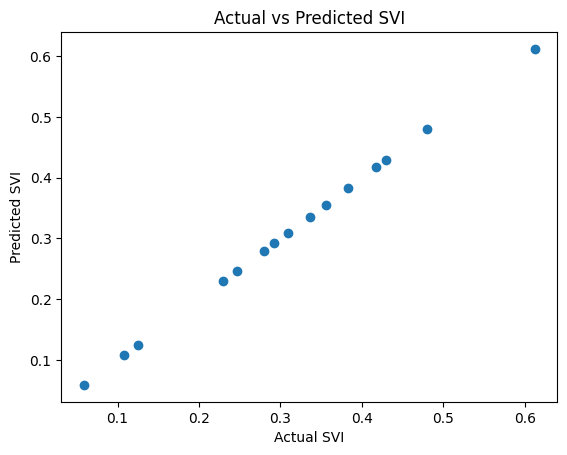

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual SVI")
plt.ylabel("Predicted SVI")
plt.title("Actual vs Predicted SVI")
plt.show()

In [12]:
test_df['Prediction_Error'] = abs(
    test_df['SVI'] - test_df['Predicted_SVI']
)

/tmp/ipykernel_1768/1897391026.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Prediction_Error'] = abs(


In [13]:
test_df.to_csv("future_svi_predictions.csv", index=False)